# Регрессия для CC50

В этом ноутбуке решается задача регрессии для целевой переменной `CC50, mM`.

`CC50` показывает цитотоксическую концентрацию соединения.
Чем выше значение `CC50`, тем менее токсичным считается соединение для клеток в рамках рассматриваемого показателя.

По итогам EDA было принято решение обучать модели не на исходном наборе признаков, а на предобработанной матрице признаков.

В рамках предобработки удаляются:

- константные признаки
- почти константные признаки
- признаки с высокой взаимной корреляцией

Это позволяет сократить размерность признакового пространства, убрать малоинформативные и дублирующие признаки,
а также сделать сравнение моделей более устойчивым.

 # Импорты

In [68]:
# Библиотека для работы с предупреждениями
import warnings

# Библиотеки для работы с данными
import pandas as pd

# Разделение данных на обучающую и тестовую выборки
from sklearn.model_selection import train_test_split

# Конфигурация проекта
from sessions_tasks.classical_ml.session02.coursework_classical_ml.src.config import (
    METRICS_DIR,
    PREDICTIONS_DIR,
    RANDOM_STATE,
    TARGET_CC50,
    TEST_SIZE,
)

# Загрузка данных
from sessions_tasks.classical_ml.session02.coursework_classical_ml.src.data_loader import (
    load_coursework_dataset,
)

# Подготовка признаков и целевой переменной
from sessions_tasks.classical_ml.session02.coursework_classical_ml.src.preprocessing import (
    build_features,
    build_regression_target,
    preprocess_features,
)

# Фабрика моделей
from sessions_tasks.classical_ml.session02.coursework_classical_ml.src.model_factory import (
    get_regression_models,
)

# Запуск экспериментов
from sessions_tasks.classical_ml.session02.coursework_classical_ml.src.experiment_runner import (
    run_regression_experiment,
)

# Визуализация результатов
from sessions_tasks.classical_ml.session02.coursework_classical_ml.src.plotting import (
    plot_actual_vs_predicted,
    plot_feature_importance,
    plot_regression_results,
)

warnings.filterwarnings("ignore")

## Загрузка данных

Загрузим исходный датасет и проверим первые строки таблицы.

In [69]:
df = load_coursework_dataset()

print(f"Размер датасета: {df.shape}")

df.head()

Размер датасета: (1001, 214)


,Unnamed: 0,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,0,6.239374,175.482382,28.125000,5.094096,5.094096,0.387225,0.387225,0.417362,42.928571,...,0,0,0,0,0,0,0,0,3,0
1,1,0.771831,5.402819,7.000000,3.961417,3.961417,0.533868,0.533868,0.462473,45.214286,...,0,0,0,0,0,0,0,0,3,0
2,2,223.808778,161.142320,0.720000,2.627117,2.627117,0.543231,0.543231,0.260923,42.187500,...,0,0,0,0,0,0,0,0,3,0
3,3,1.705624,107.855654,63.235294,5.097360,5.097360,0.390603,0.390603,0.377846,41.862069,...,0,0,0,0,0,0,0,0,4,0
4,4,107.131532,139.270991,1.300000,5.150510,5.150510,0.270476,0.270476,0.429038,36.514286,...,0,0,0,0,0,0,0,0,0,0


## Подготовка признаков и целевой переменной

Сформируем матрицу признаков `X` и целевую переменную `y`.

В качестве целевой переменной используется столбец `CC50, mM`.

Из признаков исключаются служебные столбцы и все целевые переменные: `IC50, mM`, `CC50, mM`, `SI`.
По итогам EDA было принято решение, что это необходимо, чтобы не допустить утечки данных.

In [70]:
X = build_features(df)
y = build_regression_target(df, TARGET_CC50)

print(f"Размер исходной матрицы признаков X: {X.shape}")
print(f"Размер целевой переменной y: {y.shape}")
print(f"Целевая переменная: {TARGET_CC50}")

Размер исходной матрицы признаков X: (1001, 210)
Размер целевой переменной y: (1001,)
Целевая переменная: CC50, mM


## Базовая статистика целевой переменной

Посмотрим основные статистики целевой переменной `CC50, mM`.

In [71]:
y.describe()

count    1001.000000
mean      589.110728
std       642.867508
min         0.700808
25%        99.999036
50%       411.039342
75%       894.089176
max      4538.976189
Name: CC50, mM, dtype: float64

## Предобработка признаков

По итогам EDA выполним очистку признакового пространства.

Удалим:

- константные признаки, у которых во всех строках одно и то же значение
- почти константные признаки, где одно значение встречается минимум в 99% строк
- сильно коррелирующие признаки, если абсолютная Spearman-корреляция между двумя признаками не ниже 0.90

Целевую переменную не изменяем на этом этапе.

In [72]:
X_clean, preprocessing_report = preprocess_features(X)

print(f"Размер матрицы признаков до обработки: {X.shape}")
print(f"Размер матрицы признаков после обработки: {X_clean.shape}")

print(f"Удалено константных признаков: {len(preprocessing_report['constant_features'])}")
print(f"Удалено почти константных признаков: {len(preprocessing_report['near_constant_features'])}")
print(f"Удалено сильно коррелирующих признаков: {len(preprocessing_report['highly_correlated_features'])}")
print(f"Всего удалено признаков: {len(preprocessing_report['removed_features'])}")

Размер матрицы признаков до обработки: (1001, 210)
Размер матрицы признаков после обработки: (1001, 134)
Удалено константных признаков: 18
Удалено почти константных признаков: 15
Удалено сильно коррелирующих признаков: 43
Всего удалено признаков: 76


In [73]:
preprocessing_summary = pd.DataFrame(
    {
        "step": [
            "constant_features",
            "near_constant_features",
            "highly_correlated_features",
            "removed_features",
            "remaining_features",
        ],
        "count": [
            len(preprocessing_report["constant_features"]),
            len(preprocessing_report["near_constant_features"]),
            len(preprocessing_report["highly_correlated_features"]),
            len(preprocessing_report["removed_features"]),
            len(preprocessing_report["remaining_features"]),
        ],
    }
)

preprocessing_summary

,step,count
0,constant_features,18
1,near_constant_features,15
2,highly_correlated_features,43
3,removed_features,76
4,remaining_features,134


## Модели без логарифмирования целевой переменной

Сначала обучим модели на исходной целевой переменной `CC50, mM`.

В эксперимент включены:

- `DummyRegressor`
- линейная регрессия
- Ridge
- KNN
- SVR
- Random Forest
- Extra Trees
- HistGradientBoosting
- CatBoost

Ключевой метрикой сравнения будем считать `RMSE`, так как она сильнее штрафует крупные ошибки.

In [74]:
regression_models = get_regression_models(use_log_target=False)

regression_models.keys()

dict_keys(['dummy_mean', 'linear_regression', 'ridge', 'knn', 'svr_rbf', 'random_forest', 'extra_trees', 'hist_gradient_boosting', 'catboost'])

In [75]:
cc50_results, cc50_fitted_models = run_regression_experiment(
    X=X_clean,
    y=y,
    models=regression_models,
)

cc50_results["feature_set"] = "preprocessed_features"
cc50_results["target_transform"] = "original"

cc50_results

,model,cv_rmse_mean,cv_rmse_std,train_rows,test_rows,fit_time_sec,mae,rmse,r2,mape,feature_set,target_transform
0,extra_trees,433.277753,47.923345,800,201,1.483941,272.054280,443.905849,0.619920,294.073992,preprocessed_features,original
1,catboost,431.893184,50.346378,800,201,4.391843,275.129008,445.414926,0.617332,330.128589,preprocessed_features,original
2,random_forest,442.410298,34.507925,800,201,3.268330,283.789665,450.139918,0.609170,341.651297,preprocessed_features,original
3,hist_gradient_boosting,472.888979,50.037013,800,201,1.806643,282.717891,457.855119,0.595658,309.799834,preprocessed_features,original
4,knn,479.194402,41.177545,800,201,0.043060,301.352479,506.468085,0.505237,299.299800,preprocessed_features,original
5,ridge,480.575907,43.591366,800,201,0.032844,376.735603,537.158664,0.443458,531.243900,preprocessed_features,original
6,linear_regression,493.401999,43.733709,800,201,0.033837,386.766798,556.043648,0.403637,546.711099,preprocessed_features,original
7,dummy_mean,618.981828,53.354106,800,201,0.014644,511.729334,723.054208,-0.008404,975.844439,preprocessed_features,original
8,svr_rbf,621.460198,63.813773,800,201,0.086349,471.674200,731.704646,-0.032677,603.589386,preprocessed_features,original


## Сохранение метрик без логарифмирования

Сохраним таблицу метрик для эксперимента с исходной целевой переменной.

In [76]:
cc50_results.to_csv(
    METRICS_DIR / "regression_cc50_metrics.csv",
    index=False,
)

cc50_results

,model,cv_rmse_mean,cv_rmse_std,train_rows,test_rows,fit_time_sec,mae,rmse,r2,mape,feature_set,target_transform
0,extra_trees,433.277753,47.923345,800,201,1.483941,272.054280,443.905849,0.619920,294.073992,preprocessed_features,original
1,catboost,431.893184,50.346378,800,201,4.391843,275.129008,445.414926,0.617332,330.128589,preprocessed_features,original
2,random_forest,442.410298,34.507925,800,201,3.268330,283.789665,450.139918,0.609170,341.651297,preprocessed_features,original
3,hist_gradient_boosting,472.888979,50.037013,800,201,1.806643,282.717891,457.855119,0.595658,309.799834,preprocessed_features,original
4,knn,479.194402,41.177545,800,201,0.043060,301.352479,506.468085,0.505237,299.299800,preprocessed_features,original
5,ridge,480.575907,43.591366,800,201,0.032844,376.735603,537.158664,0.443458,531.243900,preprocessed_features,original
6,linear_regression,493.401999,43.733709,800,201,0.033837,386.766798,556.043648,0.403637,546.711099,preprocessed_features,original
7,dummy_mean,618.981828,53.354106,800,201,0.014644,511.729334,723.054208,-0.008404,975.844439,preprocessed_features,original
8,svr_rbf,621.460198,63.813773,800,201,0.086349,471.674200,731.704646,-0.032677,603.589386,preprocessed_features,original


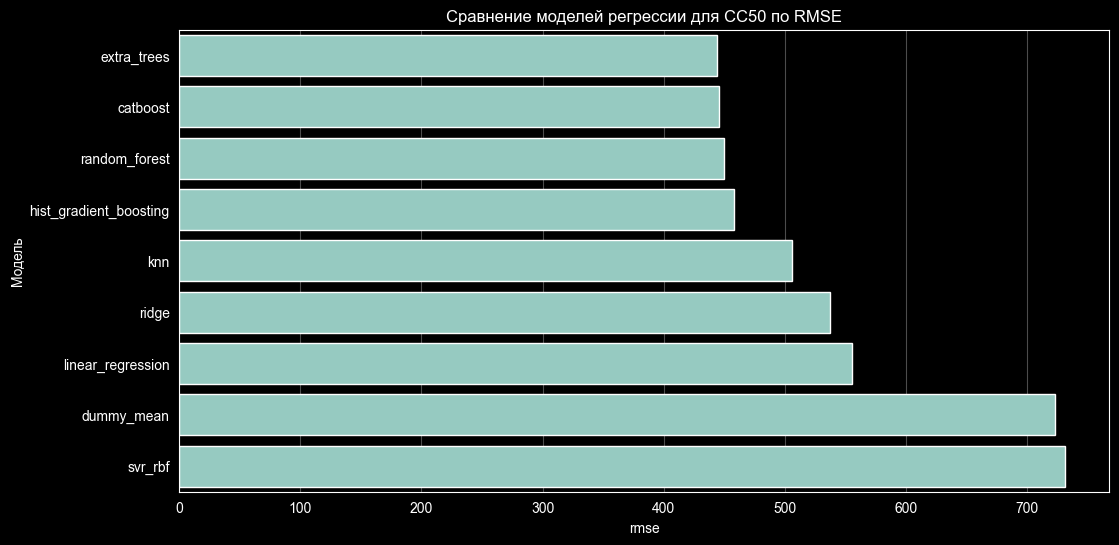

In [77]:
plot_regression_results(
    results_df=cc50_results,
    metric="rmse",
    title="Сравнение моделей регрессии для CC50 по RMSE",
)

## Модели с логарифмированием целевой переменной

Так как в EDA было видно, что целевые переменные имеют асимметричные распределения и выбросы,
дополнительно проверим вариант с логарифмированием целевой переменной.

В этом случае модель обучается не на исходном `CC50`, а на `log1p(CC50)`.

После получения прогноза выполняется обратное преобразование через `expm1`, поэтому итоговые метрики считаются в исходном масштабе `CC50, mM`.

Такой подход помогает, когда модель плохо работает из-за редких очень больших значений целевой переменной.

In [78]:
regression_log_models = get_regression_models(use_log_target=True)

regression_log_models.keys()

dict_keys(['dummy_mean_log_target', 'linear_regression_log_target', 'ridge_log_target', 'knn_log_target', 'svr_rbf_log_target', 'random_forest_log_target', 'extra_trees_log_target', 'hist_gradient_boosting_log_target', 'catboost_log_target'])

In [79]:
cc50_log_results, cc50_log_fitted_models = run_regression_experiment(
    X=X_clean,
    y=y,
    models=regression_log_models,
)

cc50_log_results["feature_set"] = "preprocessed_features"
cc50_log_results["target_transform"] = "log1p"

cc50_log_results

,model,cv_rmse_mean,cv_rmse_std,train_rows,test_rows,fit_time_sec,mae,rmse,r2,mape,feature_set,target_transform
0,extra_trees_log_target,472.635378,82.211887,800,201,1.789168,274.140396,490.985334,0.535025,122.571718,preprocessed_features,log1p
1,hist_gradient_boosting_log_target,492.882315,76.631436,800,201,2.346311,284.059968,499.531529,0.518697,135.538848,preprocessed_features,log1p
2,catboost_log_target,470.490460,82.852591,800,201,5.764703,291.034140,499.896873,0.517992,137.123116,preprocessed_features,log1p
3,svr_rbf_log_target,490.968533,67.369243,800,201,0.092371,300.976284,502.457400,0.513042,159.286410,preprocessed_features,log1p
4,random_forest_log_target,487.434554,75.993541,800,201,3.367706,298.057464,520.079604,0.478286,124.068457,preprocessed_features,log1p
5,knn_log_target,488.341638,68.522754,800,201,0.032419,314.594411,560.371476,0.394318,163.061316,preprocessed_features,log1p
6,ridge_log_target,601.015455,60.479130,800,201,0.034783,396.077764,651.588978,0.181082,187.134229,preprocessed_features,log1p
7,dummy_mean_log_target,697.230696,60.424094,800,201,0.015074,522.228365,818.159384,-0.291127,433.284950,preprocessed_features,log1p
8,linear_regression_log_target,658.786478,102.151608,800,201,0.037854,547.696296,2305.767473,-9.254724,352.711535,preprocessed_features,log1p


## Сохранение метрик логарифмического эксперимента

Сохраним таблицу метрик для эксперимента с логарифмированием целевой переменной.

In [80]:
cc50_log_results.to_csv(
    METRICS_DIR / "regression_cc50_log_target_metrics.csv",
    index=False,
)

cc50_log_results

,model,cv_rmse_mean,cv_rmse_std,train_rows,test_rows,fit_time_sec,mae,rmse,r2,mape,feature_set,target_transform
0,extra_trees_log_target,472.635378,82.211887,800,201,1.789168,274.140396,490.985334,0.535025,122.571718,preprocessed_features,log1p
1,hist_gradient_boosting_log_target,492.882315,76.631436,800,201,2.346311,284.059968,499.531529,0.518697,135.538848,preprocessed_features,log1p
2,catboost_log_target,470.490460,82.852591,800,201,5.764703,291.034140,499.896873,0.517992,137.123116,preprocessed_features,log1p
3,svr_rbf_log_target,490.968533,67.369243,800,201,0.092371,300.976284,502.457400,0.513042,159.286410,preprocessed_features,log1p
4,random_forest_log_target,487.434554,75.993541,800,201,3.367706,298.057464,520.079604,0.478286,124.068457,preprocessed_features,log1p
5,knn_log_target,488.341638,68.522754,800,201,0.032419,314.594411,560.371476,0.394318,163.061316,preprocessed_features,log1p
6,ridge_log_target,601.015455,60.479130,800,201,0.034783,396.077764,651.588978,0.181082,187.134229,preprocessed_features,log1p
7,dummy_mean_log_target,697.230696,60.424094,800,201,0.015074,522.228365,818.159384,-0.291127,433.284950,preprocessed_features,log1p
8,linear_regression_log_target,658.786478,102.151608,800,201,0.037854,547.696296,2305.767473,-9.254724,352.711535,preprocessed_features,log1p


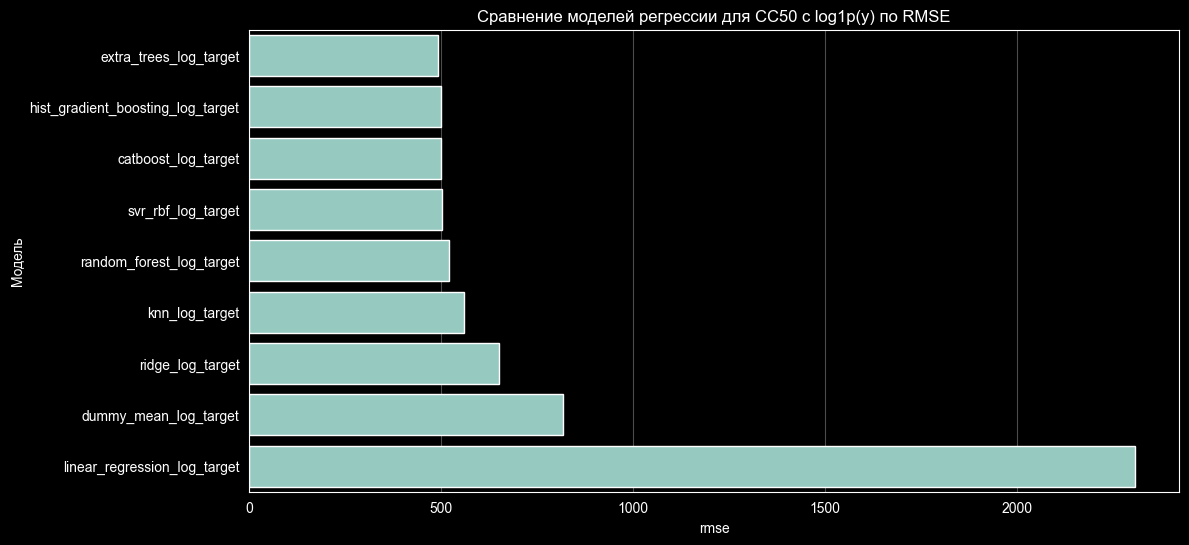

In [81]:
plot_regression_results(
    results_df=cc50_log_results,
    metric="rmse",
    title="Сравнение моделей регрессии для CC50 с log1p(y) по RMSE",
)

## Сравнение всех экспериментов

Объединим результаты моделей без логарифмирования и с логарифмированием целевой переменной.

Лучшей моделью будем считать модель с минимальным значением `RMSE`.
При близких значениях `RMSE` дополнительно можно смотреть на `MAE` и `R2`.

In [82]:
cc50_all_results = (
    pd.concat(
        [
            cc50_results,
            cc50_log_results,
        ],
        ignore_index=True,
    )
    .sort_values(by=["rmse", "mae"], ascending=True)
    .reset_index(drop=True)
)

cc50_all_results.to_csv(
    METRICS_DIR / "regression_cc50_all_metrics.csv",
    index=False,
)

cc50_all_results

,model,cv_rmse_mean,cv_rmse_std,train_rows,test_rows,fit_time_sec,mae,rmse,r2,mape,feature_set,target_transform
0,extra_trees,433.277753,47.923345,800,201,1.483941,272.054280,443.905849,0.619920,294.073992,preprocessed_features,original
1,catboost,431.893184,50.346378,800,201,4.391843,275.129008,445.414926,0.617332,330.128589,preprocessed_features,original
2,random_forest,442.410298,34.507925,800,201,3.268330,283.789665,450.139918,0.609170,341.651297,preprocessed_features,original
3,hist_gradient_boosting,472.888979,50.037013,800,201,1.806643,282.717891,457.855119,0.595658,309.799834,preprocessed_features,original
4,extra_trees_log_target,472.635378,82.211887,800,201,1.789168,274.140396,490.985334,0.535025,122.571718,preprocessed_features,log1p
5,hist_gradient_boosting_log_target,492.882315,76.631436,800,201,2.346311,284.059968,499.531529,0.518697,135.538848,preprocessed_features,log1p
6,catboost_log_target,470.490460,82.852591,800,201,5.764703,291.034140,499.896873,0.517992,137.123116,preprocessed_features,log1p
7,svr_rbf_log_target,490.968533,67.369243,800,201,0.092371,300.976284,502.457400,0.513042,159.286410,preprocessed_features,log1p
8,knn,479.194402,41.177545,800,201,0.043060,301.352479,506.468085,0.505237,299.299800,preprocessed_features,original
9,random_forest_log_target,487.434554,75.993541,800,201,3.367706,298.057464,520.079604,0.478286,124.068457,preprocessed_features,log1p


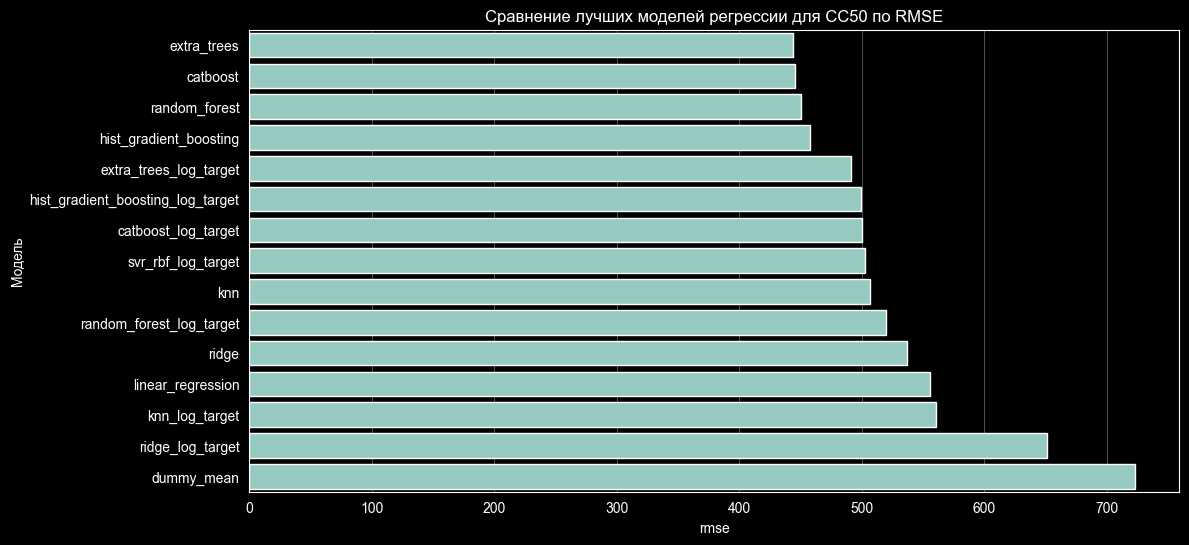

In [83]:
plot_regression_results(
    results_df=cc50_all_results.head(15),
    metric="rmse",
    title="Сравнение лучших моделей регрессии для CC50 по RMSE",
)

## Выбор лучшей модели

Выберем модель с минимальным значением `RMSE`.

In [84]:
best_result = cc50_all_results.iloc[0]

best_result

model                         extra_trees
cv_rmse_mean                   433.277753
cv_rmse_std                     47.923345
train_rows                            800
test_rows                             201
fit_time_sec                     1.483941
mae                             272.05428
rmse                           443.905849
r2                                0.61992
mape                           294.073992
feature_set         preprocessed_features
target_transform                 original
Name: 0, dtype: object

In [85]:
best_model_name = best_result["model"]
best_feature_set = best_result["feature_set"]
best_target_transform = best_result["target_transform"]

print(f"Лучшая модель: {best_model_name}")
print(f"Набор признаков: {best_feature_set}")
print(f"Преобразование целевой переменной: {best_target_transform}")
print(f"RMSE: {best_result['rmse']:.4f}")
print(f"MAE: {best_result['mae']:.4f}")
print(f"R2: {best_result['r2']:.4f}")
print(f"MAPE: {best_result['mape']:.4f}")

Лучшая модель: extra_trees
Набор признаков: preprocessed_features
Преобразование целевой переменной: original
RMSE: 443.9058
MAE: 272.0543
R2: 0.6199
MAPE: 294.0740


## Получение лучшей обученной модели

Получим лучшую обученную модель из словаря моделей.

Если лучшая модель обучалась на исходной целевой переменной, берем ее из `cc50_fitted_models`.

Если лучшая модель обучалась с логарифмированием целевой переменной, берем ее из `cc50_log_fitted_models`.

In [86]:
if best_target_transform == "original":
    best_model = cc50_fitted_models[best_model_name]
else:
    best_model = cc50_log_fitted_models[best_model_name]

best_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a fe

## Получение предсказаний лучшей модели

Повторим разбиение на train/test с теми же параметрами `TEST_SIZE` и `RANDOM_STATE`,
которые используются внутри функции запуска эксперимента.

Это необходимо, чтобы получить ту же тестовую выборку и сохранить предсказания лучшей модели.

In [87]:
X_train, X_test, y_train, y_test = train_test_split(
    X_clean,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

y_pred = best_model.predict(X_test)

best_predictions = pd.DataFrame(
    {
        "y_true": y_test,
        "y_pred": y_pred,
    }
)

best_predictions.to_csv(
    PREDICTIONS_DIR / "regression_cc50_best_predictions.csv",
    index=False,
)

best_predictions.head()

,y_true,y_pred
521,1078.062506,1081.437843
941,152.598422,480.355952
741,728.767744,795.718401
980,34.000250,82.152724
411,102.140409,579.390717


## График фактических и предсказанных значений

Построим график фактических и предсказанных значений.

Пунктирная линия показывает идеальное совпадение прогноза с фактическим значением.
Чем ближе точки к этой линии, тем точнее модель.

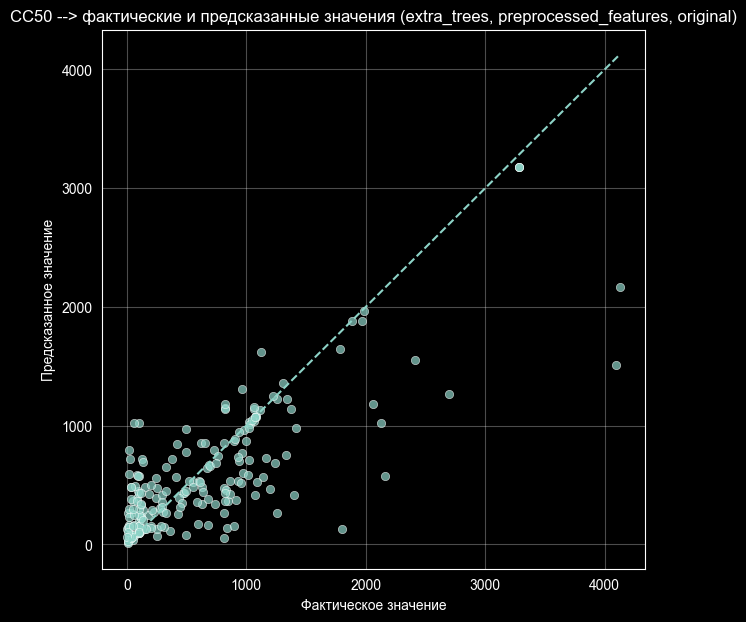

In [88]:
plot_actual_vs_predicted(
    y_true=y_test,
    y_pred=y_pred,
    title=(
        f"CC50 --> фактические и предсказанные значения "
        f"({best_model_name}, {best_feature_set}, {best_target_transform})"
    ),
)

## Важность признаков

Для лучшей модели попробуем вывести важность признаков.

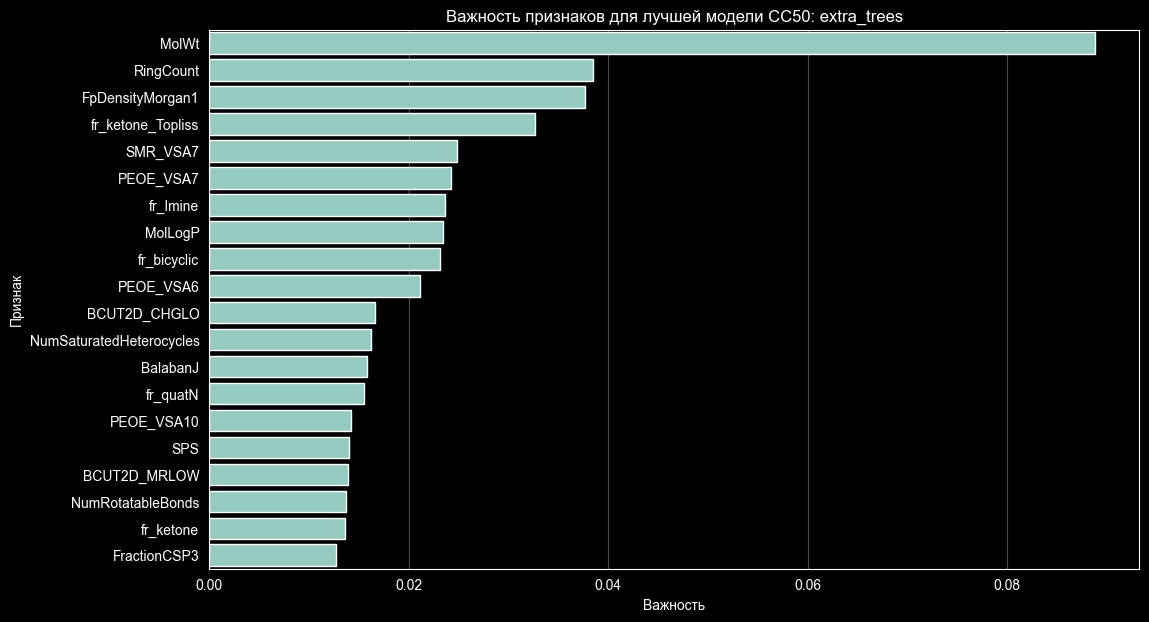

In [89]:
try:
    feature_importance_df = plot_feature_importance(
        model=best_model,
        feature_names=X_clean.columns.tolist(),
        top_n=20,
        title=f"Важность признаков для лучшей модели CC50: {best_model_name}",
    )

    feature_importance_df.head(20)
except ValueError as error:
    print(error)

# Вывод по задаче регрессии CC50

Для прогнозирования показателя `CC50, mM` были обучены несколько моделей регрессии:

- DummyRegressor
- Линейная регрессия
- Ridge
- KNN
- SVR
- Random Forest
- Extra Trees
- HistGradientBoosting
- CatBoost

В качестве признакового пространства использовались предобработанные признаки, полученные по итогам EDA.

На этапе предобработки были удалены:

* 18 константных признаков
* 15 почти константных признаков
* 43 сильно коррелирующих признака
* всего удалено 76 признаков
* после обработки осталось 134 признака из исходных 210

Целевая переменная CC50, mM также имеет выраженную правостороннюю асимметрию.
Медианное значение составляет около 411.04, среднее значение около 589.11, а максимальное значение достигает 4538.98.
Это говорит о наличии крупных значений и выбросов, из-за которых задача регрессии становится сложнее.

Были проверены два варианта обучения:

1. обучение на исходной целевой переменной
2. обучение на логарифмированной целевой переменной log1p(y) с последующим обратным преобразованием предсказаний

По итогам сравнения лучшей моделью стала ExtraTreesRegressor, обученная на предобработанных признаках и на исходной целевой переменной.

Основные метрики лучшей модели:

* RMSE: 443.9058
* MAE: 272.0543
* R2: 0.6199
* MAPE: 294.0740

Модель заметно превосходит константную базовую модель DummyRegressor,
у которой RMSE составляет около 723.05, а R2 близок к нулю и имеет отрицательное значение.
Это означает, что модель действительно использует информацию из молекулярных дескрипторов,
а не просто предсказывает среднее значение CC50.

Значение R2 = 0.6199 показывает, что модель объясняет около 62% вариативности целевой переменной на тестовой выборке.
Для данной задачи это заметно лучше, чем в задаче прогнозирования IC50, где качество было ниже.

На графике фактических и предсказанных значений видно, что модель в целом лучше улавливает зависимость для малых и средних значений CC50.
При этом для отдельных объектов с очень высокими значениями целевой переменной модель все еще может ошибаться,
часть крупных значений предсказывается ниже фактических, что характерно для регрессии при наличии выбросов.

Логарифмирование целевой переменной не дало лучшего результата по ключевой метрике RMSE в исходном масштабе.
Лучшие модели с log1p(y) уступили варианту ExtraTreesRegressor на исходной целевой переменной.
Поэтому для задачи регрессии CC50 в качестве основной модели выбран вариант без логарифмирования.

Анализ важности признаков для лучшей модели показывает, что наибольший вклад в прогноз вносят признаки
`MolWt`, `RingCount`, `FpDensityMorgan1`, `fr_ketone_Topliss`, `SMR_VSA7`, `PEOE_VSA7`, `fr_Imine`, `MolLogP`.

### Итог

Для задачи прогнозирования `CC50, mM` лучшей моделью является `ExtraTreesRegressor`
на предобработанных признаках без логарифмирования целевой переменной.
Модель показывает приемлемое качество и заметно превосходит базовый константный прогноз,
однако ошибки на крупных значениях CC50 сохраняются из-за асимметрии распределения и выбросов.